<a href="https://colab.research.google.com/github/paringupta/AE498/blob/main/AE498HW_3Problem_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GRSS Example
This notebook is intended to serve as an example on how to perform orbit determination with the Gauss Radau Solar System propagator package. https://rahil-makadia.github.io/grss/


In [3]:
import sys
!{sys.executable} -m pip install grss

# import GRSS
from grss import fit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 70.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.7/313.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.4/579.4 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 54.0 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing install

In [4]:
# import other numpy and time converter via astropy
import numpy as np
np.set_printoptions(precision=10, linewidth=np.inf)

from astropy.time import Time

In [5]:
# import matplotlib based plotting routines

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
# matplotlib.rcParams['mathtext.fontset'] = 'stix'
# matplotlib.rcParams['font.family'] = 'STIXGeneral'
# matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'serif'

font = {'family' : 'serif',
         'size'   : 11,
         'serif':  'cmr10'
         }

matplotlib.rc('font', **font)
matplotlib.rcParams["axes.formatter.use_mathtext"] = True


In [6]:
60522 - 37.85603512/ 0.46505147

60440.598182003385

## Initial conditions for the target asteroid
If the asteroid is named a query from the NASA Small Body Database can provide initial orbits and covariances. Alternatively, one can also add a user provided Initial Orbit with Covariances as well as user determined acceleration values a1, a2 and a3, as well as scaling paratmeters for a Marsden-like non-gravitational force model.

In [8]:
# NASA Small Body Database designation of Solar System Object
body_id = 'SYNTH'

try:
    init_sol, init_cov, nongrav_info = fit.get_sbdb_info(body_id)

except:
    print(f"Failed to get SBDB info for {body_id}. Reverting to user supplied initial orbit).")

    # --- YOUR FIND_ORB INITIAL ORBIT ---
    init_sol = {
        't': 60490.0,                          # Epoch (MJD)
        'e': 0.3905426,
        'q': 1.00828875,                       # AU
        'tp': 60442.32323,                     # Time of perihelion (MJD)
        'om': np.deg2rad(214.44311),           # Longitude of ascending node [rad]
        'w': np.deg2rad(359.94542),              # Argument of perihelion [rad]
        'i': np.deg2rad(10.68657)              # Inclination [rad]
    }

    # Initial covariance (just a starting guess)
    init_cov = 0.1 * np.identity(6)

    # Non-gravitational parameters (leave as zero)
    nongrav_info = {
        'a1': 0.0,
        'a2': 0.0,
        'a3': 0.0,
        'alpha': 1.0,
        'k': 0.0,
        'm': 2.0,
        'n': 0.0,
        'r0_au': 1.0,
        'radius': 0.0,
    }

# specify JPL DExxx kernel used for planetary ephemerides
de_kernel = 440

Failed to get SBDB info for SYNTH. Reverting to user supplied initial orbit).


In [9]:
214.42379 / 180 * np.pi

3.742401130104892

In [10]:
359.96368 / 180 * np.pi

6.282551403595263

In [11]:
10.68883 / 180 * np.pi

0.1865552766859455

In [12]:
# activate non-gravitaional forces

add_a1 = False
add_a2 = False
add_a3 = False
ng_guess = 1e-13
if add_a1:
    # add a1 to init_sol
    init_sol['a1'] = ng_guess
    # add row and column for a1 to init_cov
    init_cov = np.pad(init_cov, ((0,1),(0,1)), mode='constant', constant_values=ng_guess**2)
if add_a2:
    # add a2 to init_sol
    init_sol['a2'] = ng_guess
    # add row and column for a2 to init_cov
    init_cov = np.pad(init_cov, ((0,1),(0,1)), mode='constant', constant_values=ng_guess**2)
if add_a3:
    # add a3 to init_sol
    init_sol['a3'] = ng_guess
    # add row and column for a3 to init_cov
    init_cov = np.pad(init_cov, ((0,1),(0,1)), mode='constant', constant_values=ng_guess**2)

## Determine parameters for the Least Squares filtering of observations

In [13]:
# add observations by the ESA's Gaia satellite (requires special treatment)
add_gaia_obs = False

# restrict timespan observations are considered for
t_min_tdb = None
t_max_tdb = None
# use lower resolution asteroid catalog debiasing scheme (JPL default, see Eggl+ 2020)
debias_lowres = False
# deweight outlier observations rather than eliminate them
deweight = True
eliminate = False
# limit the number of observations per night used in the fit. Avoids biases toward single nights that have many observations
num_obs_per_night = 4
# verbose filtering feedback
verbose = True


## Read in optical observations from File

In [15]:
# add additional file containing observations in ADES format
optical_obs_file = "/content/2024pdc25.xml"

# # get optical observations from file
obs_df = fit.get_optical_obs(body_id, optical_obs_file, t_min_tdb, t_max_tdb, debias_lowres, deweight, eliminate, num_obs_per_night, verbose)


Read in 98 observations from the file.
	Filtered to 98 observations that satisfy the time range and accepted observatory constraints.
Applying Eggl et al. (2020) debiasing scheme to the observations.
	Unknown star catalog: UNK
	No debiasing needed for 0 observations.
	Debiased 0 observations.
	No bias information for 98 observations.
Applying Vereš et al. (2017) weighting scheme to the observations.
	Using 0 CCD observations with station-specific weight rules.
Applying sqrt(N/4) deweighting scheme.
	Deweighted 98 observations.


### How to Upload the File to Colab

1.  **Click the 'Files' icon** on the left sidebar (it looks like a folder).
2.  **Click the 'Upload to session storage' icon** (it looks like an upload arrow).
3.  **Select `2024pdc25.xml`** from your local machine and upload it.

Once uploaded, the file will be accessible in the Colab environment. Usually, it's placed directly in the `/content/` directory. After uploading, you can then execute the following cells to update the `optical_obs_file` variable and re-run the observation loading.

In [17]:
# Update the optical_obs_file variable to reflect the uploaded file's location
optical_obs_file = "/content/2024pdc25.xml"

# Re-run the cell to get optical observations from the uploaded file
obs_df = fit.get_optical_obs(body_id, optical_obs_file, t_min_tdb, t_max_tdb, debias_lowres, deweight, eliminate, num_obs_per_night, verbose)

# Display the head of the DataFrame to confirm successful loading
display(obs_df.head())

Read in 98 observations from the file.
	Filtered to 98 observations that satisfy the time range and accepted observatory constraints.
Applying Eggl et al. (2020) debiasing scheme to the observations.
	Unknown star catalog: UNK
	No debiasing needed for 0 observations.
	Debiased 0 observations.
	No bias information for 98 observations.
Applying Vereš et al. (2017) weighting scheme to the observations.
	Using 0 CCD observations with station-specific weight rules.
Applying sqrt(N/4) deweighting scheme.
	Deweighted 98 observations.


,permID,provID,mode,stn,prog,obsTime,rmsTime,ra,dec,rmsRA,...,biasDec,biasTime,resDelay,resDoppler,sigDelay,sigDoppler,obsTimeMJD,obsTimeMJDTDB,cosDec,resChi
0,NaN,NaN,CCD,500,NaN,2024-07-31T02:24:00.00Z,NaN,252.359367,8.056822,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60522.1,60522.100801,0.990130,NaN
1,NaN,NaN,CCD,500,NaN,2024-07-31T00:00:00.00Z,NaN,252.285371,8.098561,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60522.0,60522.000801,0.990027,NaN
2,NaN,NaN,CCD,500,NaN,2024-07-28T02:24:00.00Z,NaN,250.091267,9.330564,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60519.1,60519.100801,0.986769,NaN
3,NaN,NaN,CCD,500,NaN,2024-07-28T00:00:00.00Z,NaN,250.013854,9.373778,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60519.0,60519.000801,0.986647,NaN
4,NaN,NaN,CCD,500,NaN,2024-07-25T02:24:00.00Z,NaN,247.712908,10.647547,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60516.1,60516.100801,0.982782,NaN


In [18]:
obs_df

,permID,provID,mode,stn,prog,obsTime,rmsTime,ra,dec,rmsRA,...,biasDec,biasTime,resDelay,resDoppler,sigDelay,sigDoppler,obsTimeMJD,obsTimeMJDTDB,cosDec,resChi
0,NaN,NaN,CCD,500,NaN,2024-07-31T02:24:00.00Z,NaN,252.359367,8.056822,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60522.1,60522.100801,0.990130,NaN
1,NaN,NaN,CCD,500,NaN,2024-07-31T00:00:00.00Z,NaN,252.285371,8.098561,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60522.0,60522.000801,0.990027,NaN
2,NaN,NaN,CCD,500,NaN,2024-07-28T02:24:00.00Z,NaN,250.091267,9.330564,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60519.1,60519.100801,0.986769,NaN
3,NaN,NaN,CCD,500,NaN,2024-07-28T00:00:00.00Z,NaN,250.013854,9.373778,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60519.0,60519.000801,0.986647,NaN
4,NaN,NaN,CCD,500,NaN,2024-07-25T02:24:00.00Z,NaN,247.712908,10.647547,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60516.1,60516.100801,0.982782,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,NaN,NaN,CCD,500,NaN,2024-06-07T00:00:00.00Z,NaN,179.611383,27.683458,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60468.0,60468.000801,0.885528,NaN
94,NaN,NaN,CCD,500,NaN,2024-06-06T02:24:00.00Z,NaN,177.806604,27.583594,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60467.1,60467.100801,0.886336,NaN
95,NaN,NaN,CCD,500,NaN,2024-06-06T00:00:00.00Z,NaN,177.606354,27.570900,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60467.0,60467.000801,0.886439,NaN
96,NaN,NaN,CCD,500,NaN,2024-06-05T02:24:00.00Z,NaN,175.807604,27.442472,0.2,...,0.0,NaN,NaN,NaN,NaN,NaN,60466.1,60466.100801,0.887474,NaN


## Construct the fitting instance

In [19]:
n_iter_max = 20
fit_sim = fit.FitSimulation(init_sol, obs_df, init_cov, n_iter_max=n_iter_max, de_kernel=de_kernel, nongrav_info=nongrav_info)
fit_sim.reject_outliers = True
fit_sim.analytic_partials = True
fit_sim.reject_criteria = [2.0, 1.8]

## Perform the fit

In [20]:

fit_sim.filter_lsq()

Iteration		Unweighted RMS		Weighted RMS 		Chi-squared		Reduced Chi-squared
1			 13306.473			 2688.184			 1416361567.228			 7454534.564
2			 1690.205			 341.463			 22853043.758			 120279.178
3			 471.422			 95.237			 1777744.752			 9356.551
4			 1.503			 0.304			 18.075			 0.095
5			 0.004			 0.001			 0.000			 0.000
Converged without rejecting outliers. Starting outlier rejection now...
6			 0.004			 0.001			 0.000			 0.000
Converged after rejecting outliers. Rejected 0 out of 98 optical observations.


## Plot the results

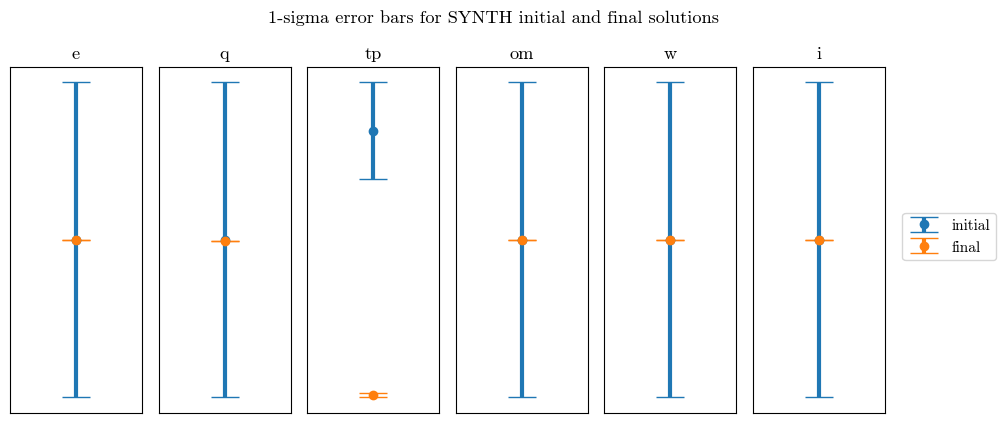

In [21]:
# plot error bars for initial and final solution
n_sig = 1
labels = ['initial', 'final']
keys = list(fit_sim.x_init.keys())
init = list(fit_sim.x_init.values())
init_sig = np.diag(fit_sim.covariance_init)**0.5
nom = list(fit_sim.x_nom.values())
nom_sig = np.diag(fit_sim.covariance)**0.5
plt.figure(figsize=(10, 4), dpi=100)
for elem_idx in range(len(keys)):
    plt.subplot(1, len(keys), elem_idx+1)
    plt.errorbar(0, init[elem_idx], yerr=init_sig[elem_idx]*n_sig, fmt='o', capsize=10, lw=3, label=labels[0])
    plt.errorbar(0, nom[elem_idx], yerr=nom_sig[elem_idx]*n_sig, fmt='o', capsize=10, lw=3, label=labels[1])
    plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
    plt.title(keys[elem_idx])
plt.legend(ncol=1, bbox_to_anchor=(1.9,0.6))
plt.tight_layout()
plt.suptitle(f'{n_sig}-sigma error bars for {body_id} initial and final solutions', y=1.05)
plt.show()

In [22]:
fit_sim.print_summary()

Summary of the orbit fit calculations after postfit pass:
RMS unweighted: 0.0036223961341846646
RMS weighted: 0.000731809396352383
chi-squared: 0.00010496681854756928
reduced chi-squared: 5.524569397240488e-07
square root of reduced chi-squared: 0.0007432744713253973
--------------------------------------------------------------
Solution Time: MJD 60490.000 TDB = 2024-06-29 00:00:00.000 TDB
Solution Observation Arc: 56.10 days (0.15 years)
--------------------------------------------------------------
Fitted Variable		Initial Value			Uncertainty			Fitted Value			Uncertainty			Change				Change (sigma)
e			3.90542600000e-01		3.16227766017e-01		3.90656383286e-01		3.99773983957e-04		+1.13783285657e-04		+0.285
q			1.00828875000e+00		3.16227766017e-01		1.00537190434e+00		3.71810930140e-05		-2.91684566330e-03		-78.450
tp			6.04423232300e+04		3.16227766017e-01		6.04405970320e+04		1.26768076218e-02		-1.72619797025e+00		-136.170
om			2.14443110000e+02		1.81185163576e+01		2.14426023144e+02		1.172

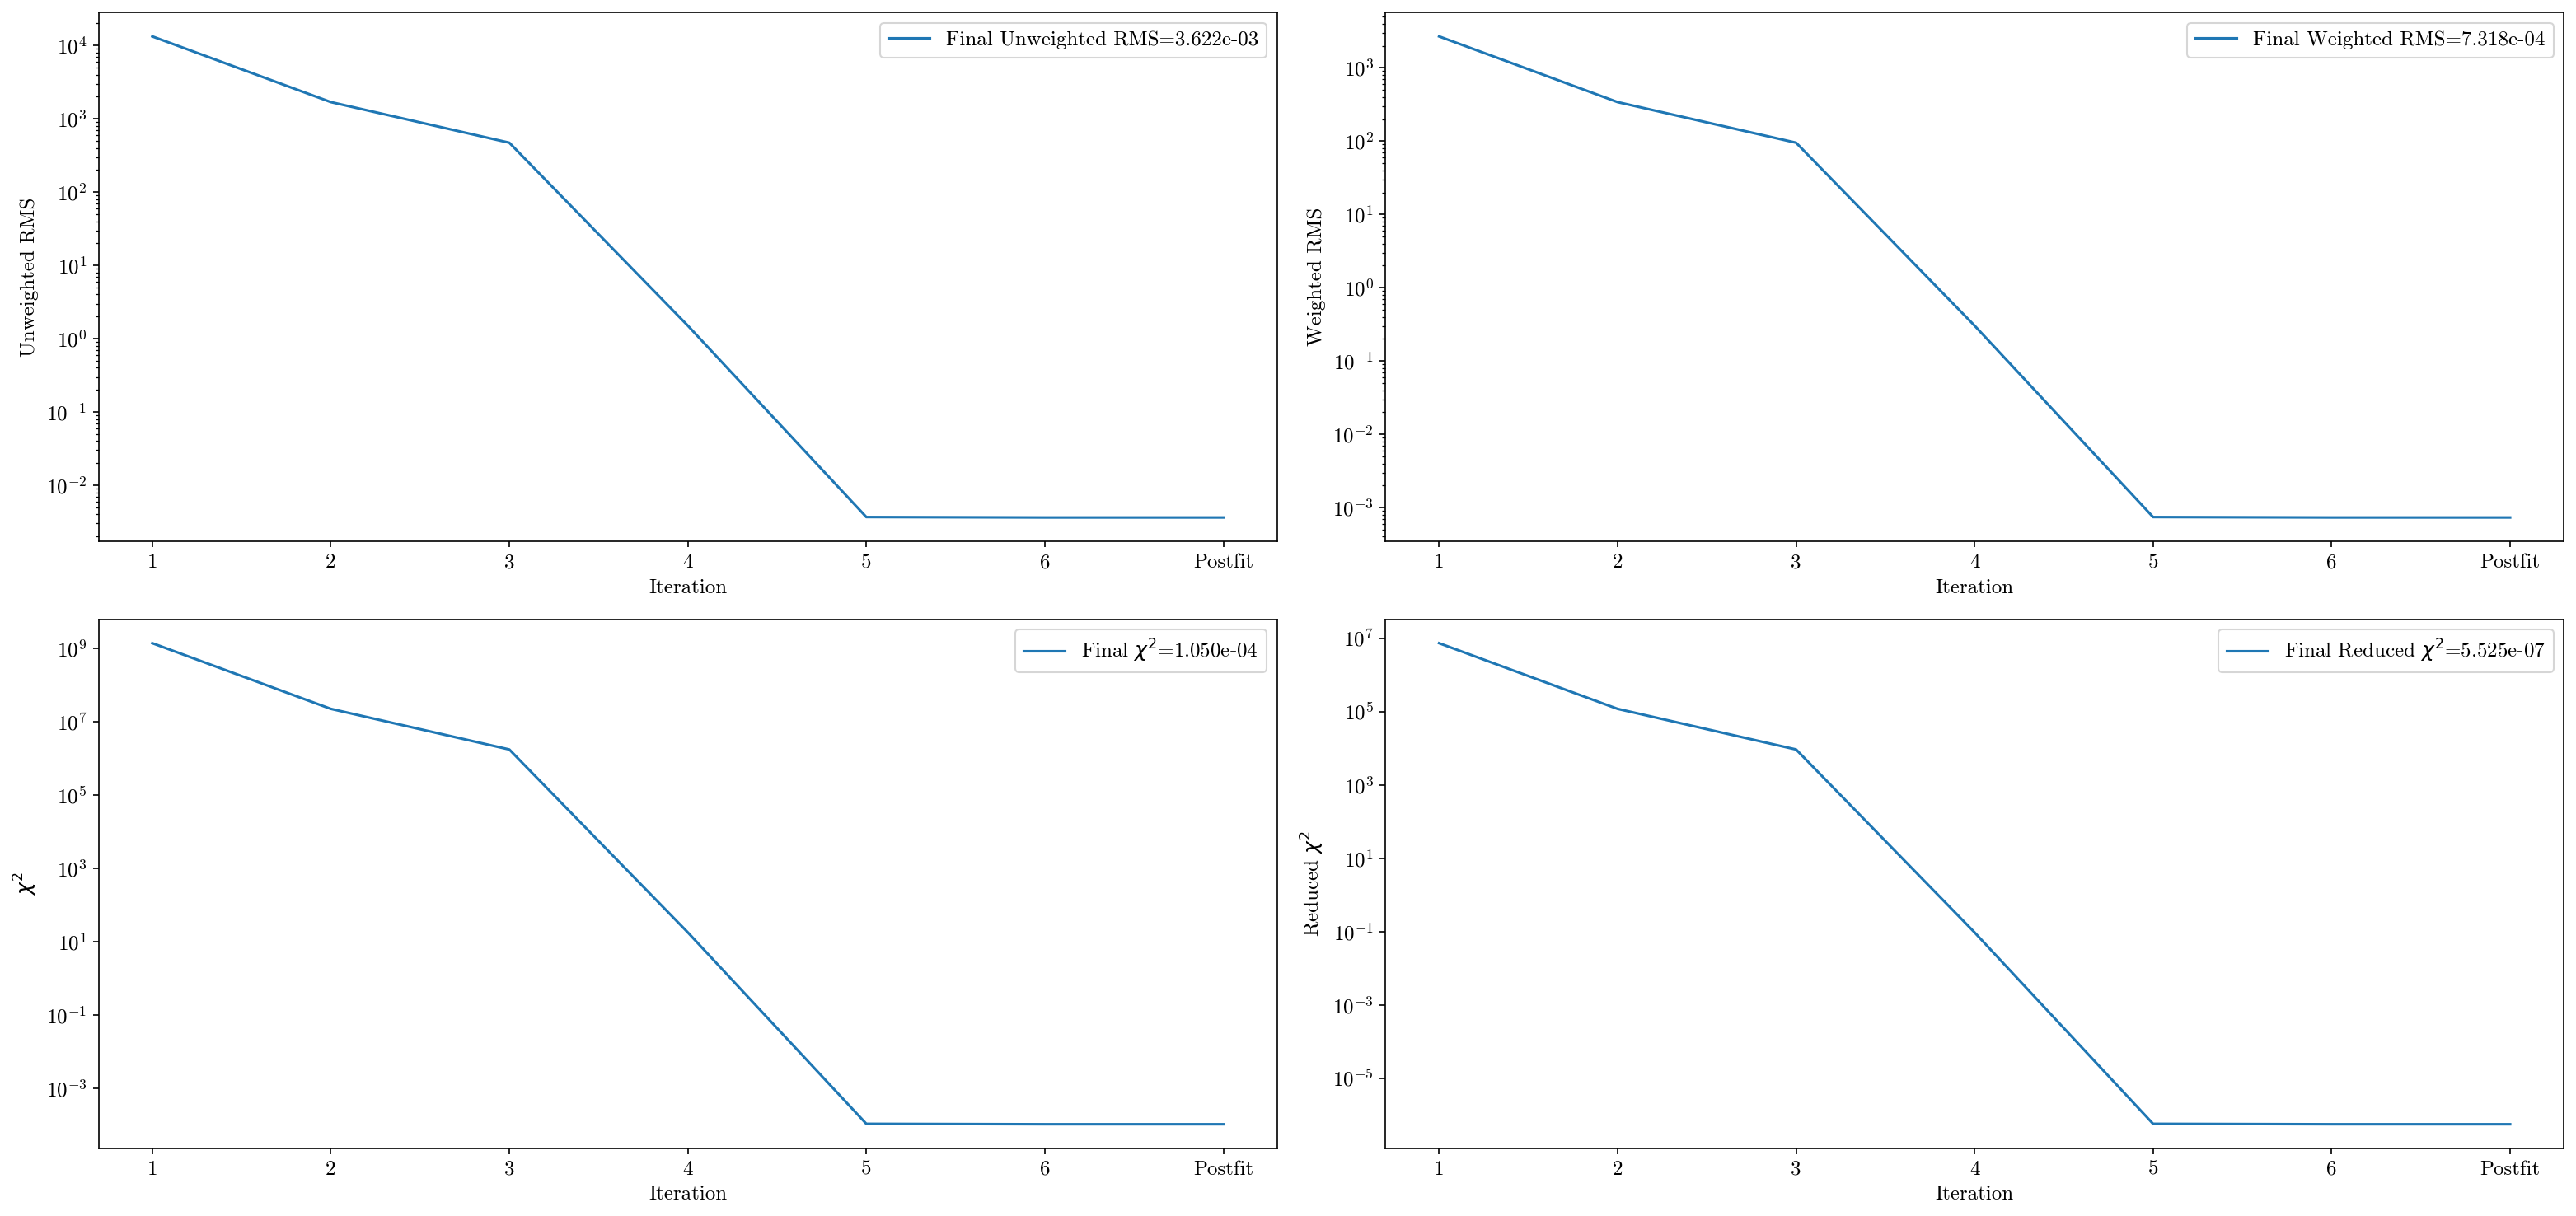

In [23]:
fit_sim.plot_summary(auto_close=True)

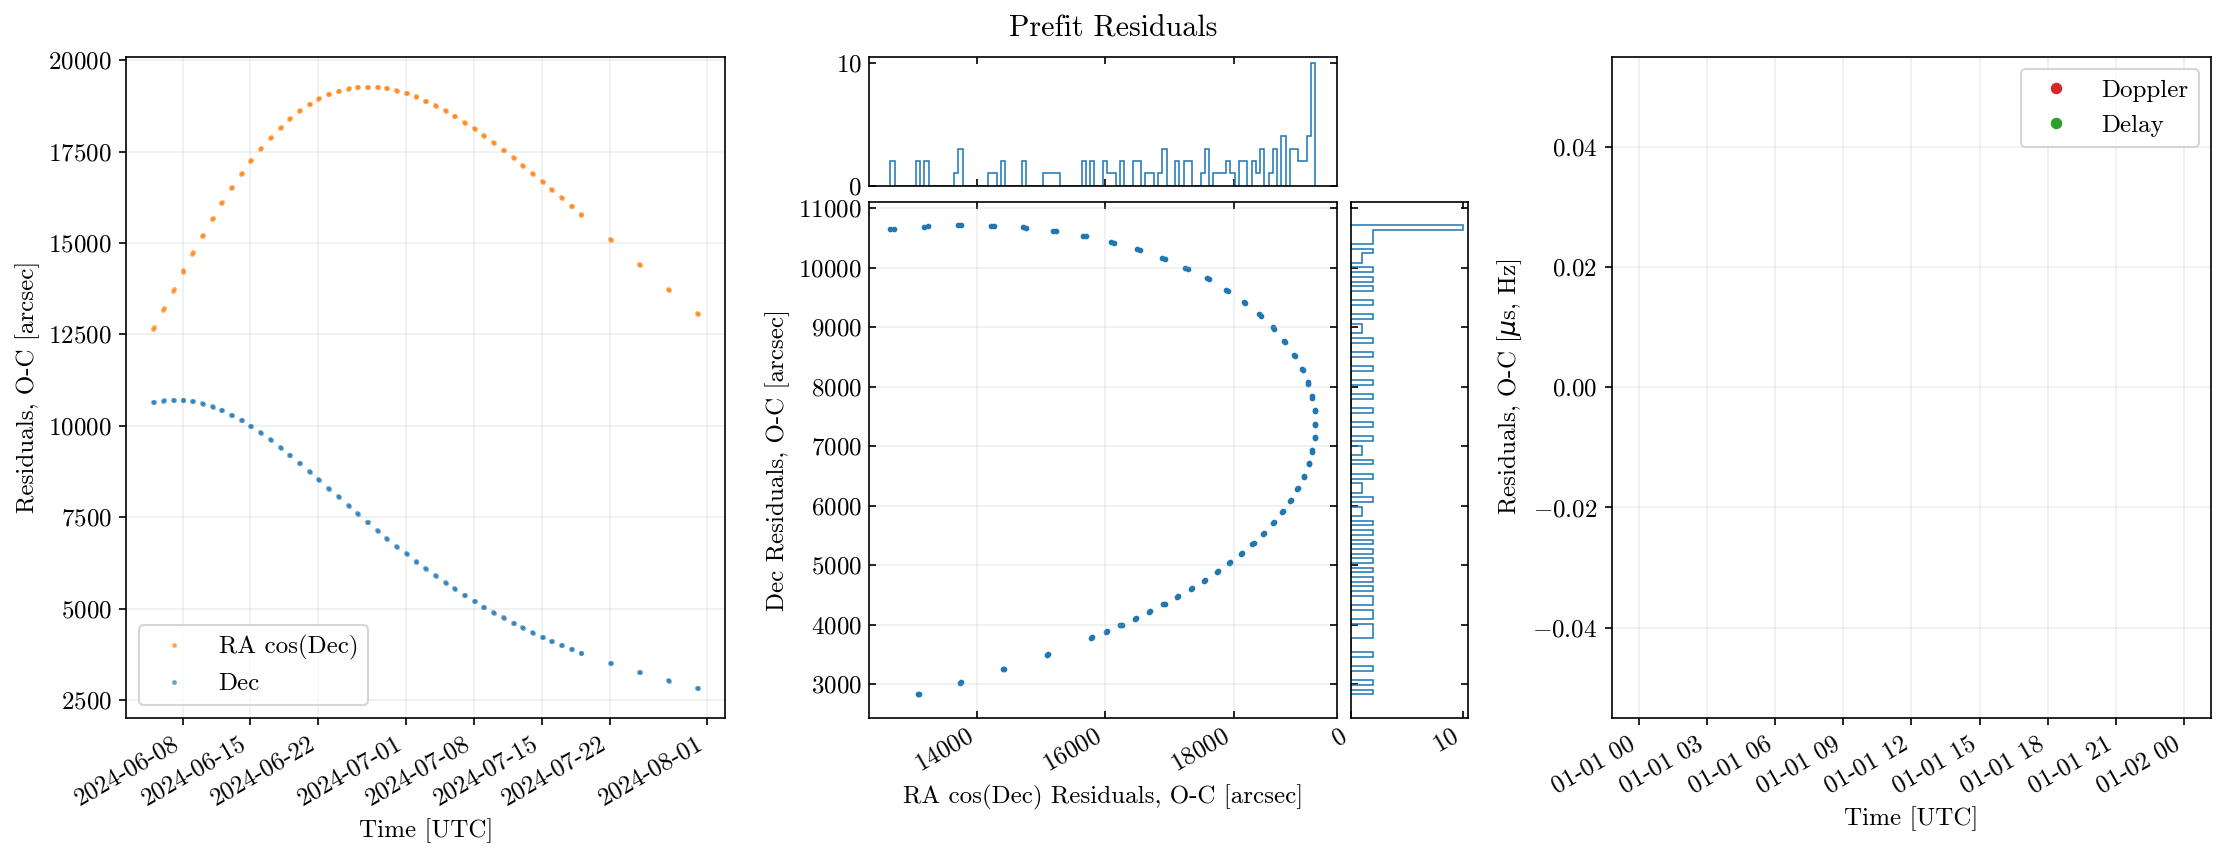

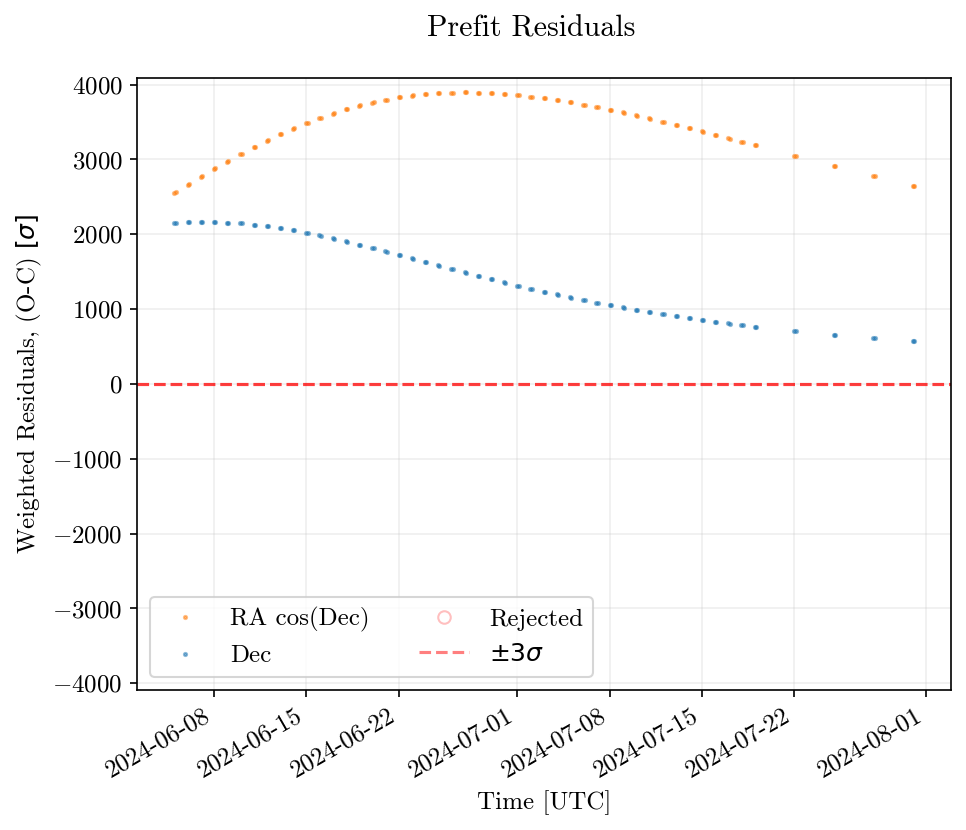

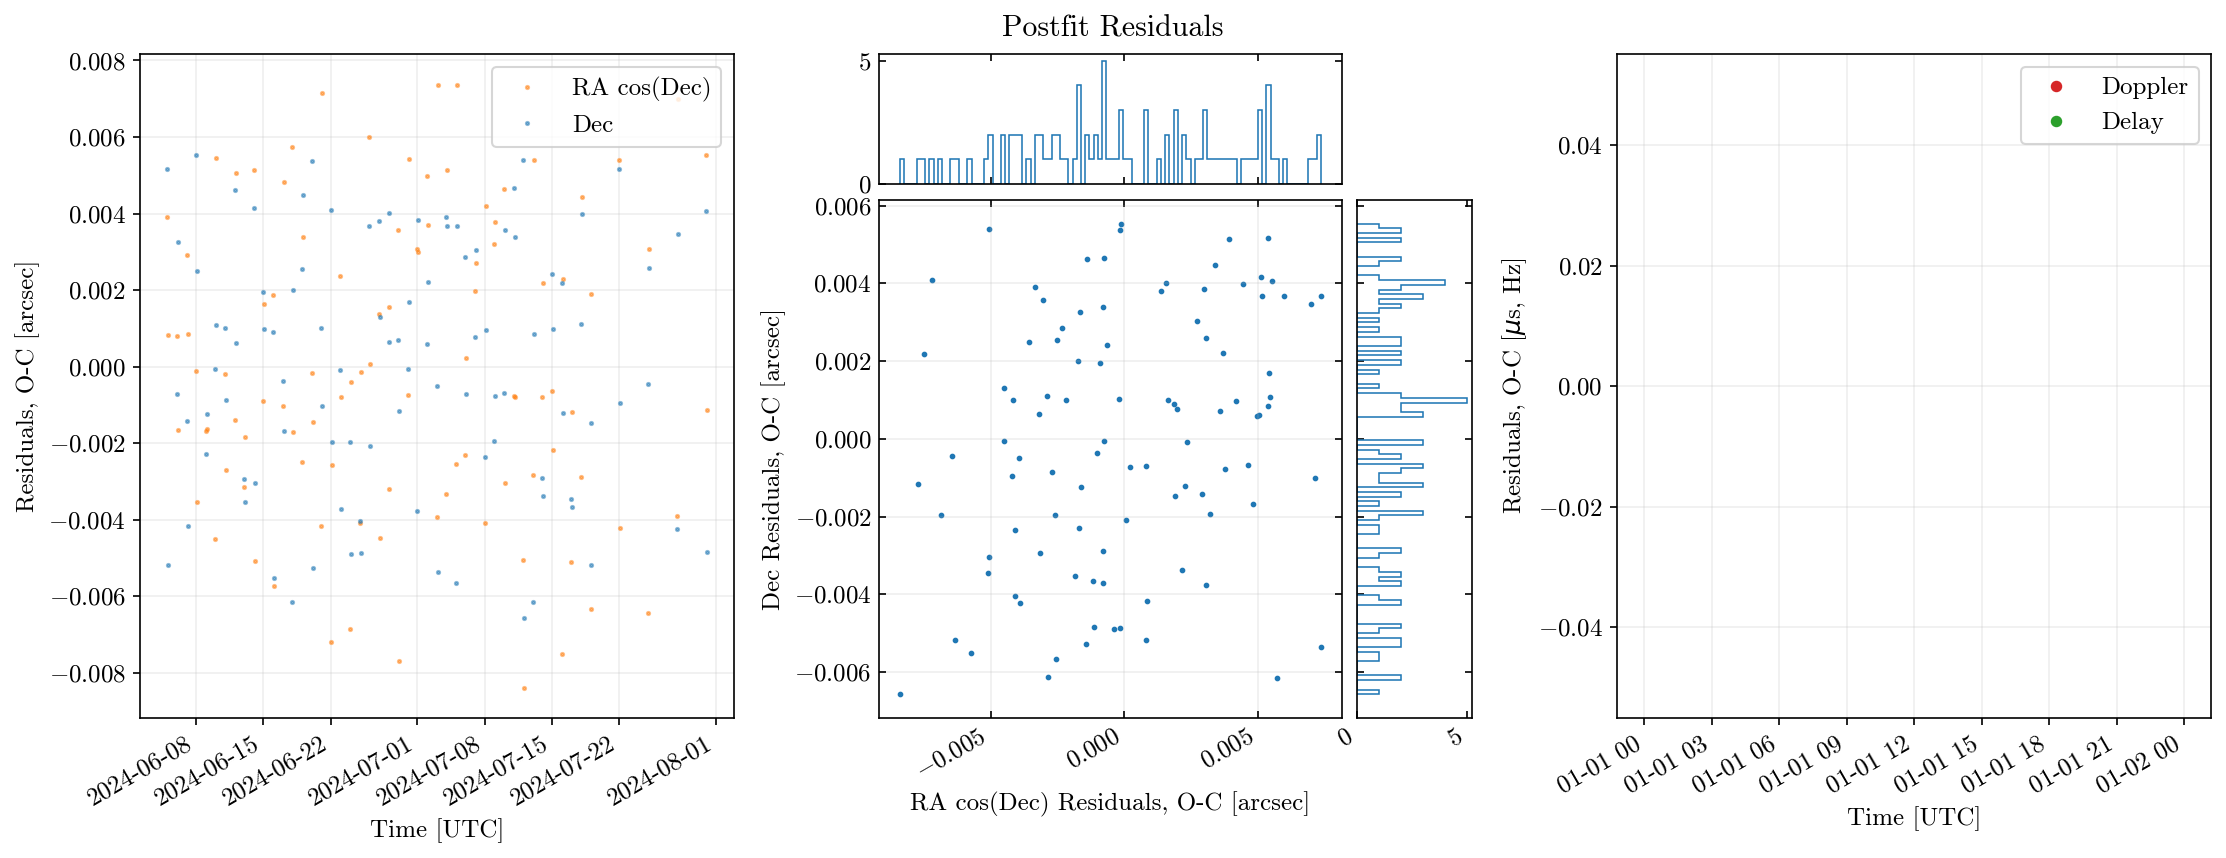

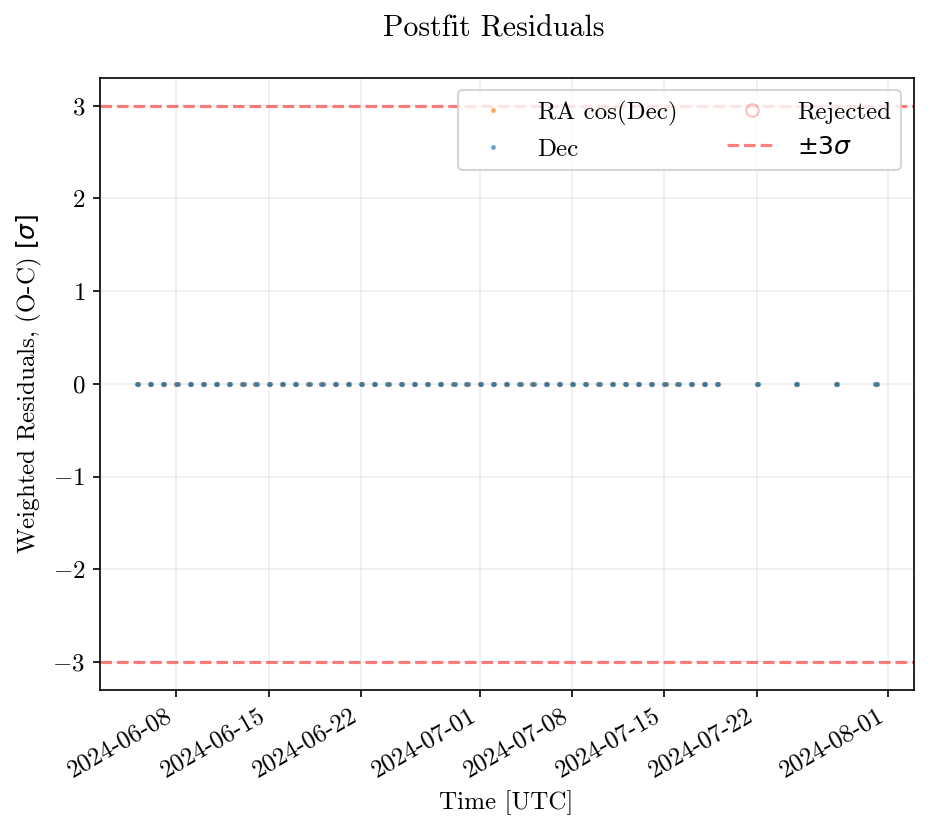

In [24]:
fit_sim.iters[1].plot_iteration_summary(title='Prefit Residuals', auto_close=True)
fit_sim.iters[-1].plot_iteration_summary(title='Postfit Residuals', auto_close=True)

In [25]:
mean_0 = np.array(list(init_sol.values())[1:])
cov_0 = init_cov
mean_f = np.array(list(fit_sim.x_nom.values()))
cov_f = fit_sim.covariance

# The condition 'np.all(init_cov != 0)' evaluates to False because 'init_cov' (a diagonal matrix)
# contains zero elements. Removing this condition to ensure similarity stats are always calculated.
maha_dist_f, maha_dist_0, bhattacharya, bhatt_coeff = fit.get_similarity_stats(mean_0, cov_0, mean_f, cov_f)
print(f'Mahalonobis distance between JPL and GRSS solution: {maha_dist_f:0.2f}')
print(f'Mahalonobis distance between GRSS and JPL solution: {maha_dist_0:0.2f}')
print(f'Bhattacharya distance between JPL and GRSS solution: {bhattacharya:0.4f}')
print(f'Bhattacharya coefficient between JPL and GRSS solution: {bhatt_coeff:0.4f}')

Mahalonobis distance between JPL and GRSS solution: 5.46
Mahalonobis distance between GRSS and JPL solution: 40523.54
Bhattacharya distance between JPL and GRSS solution: 27.7737
Bhattacharya coefficient between JPL and GRSS solution: 0.0000


In [26]:
print(mean_f)

[3.9065638329e-01 1.0053719043e+00 6.0440597032e+04 3.7424401058e+00 6.2824862006e+00 1.8655891068e-01]


In [27]:
print(cov_f)

[[ 1.5981923825e-07  1.4679012487e-08  5.0334325147e-06 -8.1399217592e-08  1.1172143036e-07  3.7238260898e-08]
 [ 1.4679012487e-08  1.3824336777e-09  4.7067695794e-07 -7.5646281343e-09  1.0528122713e-08  3.3981522211e-09]
 [ 5.0334325147e-06  4.7067695794e-07  1.6070145148e-04 -2.5857588561e-06  3.5870179594e-06  1.1666904492e-06]
 [-8.1399217592e-08 -7.5646281343e-09 -2.5857588561e-06  4.1892770273e-08 -5.7800111332e-08 -1.8879572864e-08]
 [ 1.1172143036e-07  1.0528122713e-08  3.5870179594e-06 -5.7800111332e-08  8.0446076998e-08  2.5815369920e-08]
 [ 3.7238260898e-08  3.3981522211e-09  1.1666904492e-06 -1.8879572864e-08  2.5815369920e-08  8.6997569187e-09]]
